# **Análisis Descriptivo**

Con el objetivo de evaluar si un modelo de lenguaje entrenado con datos combinados de dos dominios distintos, ofrece mejor rendimiento en tareas de clasificación de textos, que dos modelos especializados entrenados por separado y posteriormente fusionados, es necesario analizar las características de los datasets que utilizaremos durante las distintas fases del proceso de entrenamiento.

Para este trabajo hemos seleccionado dos conjuntos de datos pertenecientes a ámbitos semánticos muy diferentes: el **dominio médico** y el **dominio legal**. Esta diferencia temática es fundamental, ya que trabajar con textos que no comparten vocabulario y estilo de discurso, permite poner a prueba la capacidad real del modelo para generalizar y aprender patrones del lenguaje que no dependen de un único contexto.

Ambos datasets serán utilizados en dos fases de entrenamiento diferenciadas:

1. **Entrenamiento autosupervisado:**
En esta fase, solo utilizaremos los textos completos de cada dataset, sin considerar sus etiquetas. El objetivo es que el modelo aprenda representaciones del lenguaje (embeddings) propias de cada dominio, capturando patrones sintácticos y semánticos relevantes.

2. **Entrenamiento supervisado de la cabeza de clasificación:**
A partir de los embeddings generados en la fase anterior, entrenaremos una cabeza de clasificación utilizando las etiquetas disponibles en cada conjunto.

- **Es por ello que el análisis descriptivo** se realiza como si ambos datasets fueran puramente de clasificación, ya que, aunque el autosupervisado no requiere un tratamiento especial más allá de la recopilación de textos, la fase supervisada sí exige comprender las clases, su distribución y su significado.

Por otro lado, para garantizar un entrenamiento equilibrado entre los dos dominios, hemos submuestreado 4000 ejemplos de cada dataset, obteniendo así un tamaño homogéneo y comparable.

## **Descripción del dataset médico**

El primer conjunto de datos procede de HuggingFace:
**rungalileo / medical_transcription_4**, un dataset basado en transcripciones médicas y reportes clínicos.
Contiene textos médicos acompañados de **cuatro etiquetas** que clasifican el tipo de documento clínico:

1. **Medical Records**: Incluye registros médicos generales, como informes de evolución, revisiones clínicas o anotaciones básicas.

2. **Other**: Textos relacionados con el ámbito médico que no encajan claramente en las categorías principales (por ejemplo, notas administrativas).

3. **Internal Medicine**: Documentos relacionados con medicina interna, como diagnósticos, evaluaciones clínicas y tratamientos no quirúrgicos.

4. **Surgery**: Informes y transcripciones vinculados a procedimientos quirúrgicos, intervenciones, técnicas operatorias o evoluciones postquirúrgicas.

El dataset cuenta originalmente con 4.499 ejemplos de entrenamiento y 500 de prueba. Su formato incluye tres campos principales:

1. **id**: identificador numérico,

2. **text**: la transcripción médica,

3. **label**: la categoría clínica.

## **Descripción del dataset legal**

El segundo conjunto procede de Kaggle:
**Legal Text Classification Dataset**, recopilado por **A. Mohan Kumar**, con textos procedentes del Australian Legal Information Institute (AustLII).
Incluye 25.000 casos legales de los años 2006 a 2009, cada uno representado mediante:

1. **Case ID**: identificador único,

2. **Case Outcome**: resultado del caso judicial,

3. **Case Title**: título del caso,

4. **Case Text**: el texto completo de la resolución o sentencia.

El conjunto original contiene las siguientes etiquetas (Case Outcome), las cuales describen la forma en que un caso judicial utiliza, interpreta o contrasta las decisiones de casos anteriores, es decir, la manera en que un caso habla sobre otros casos previos y qué tipo de relación establece con ellos:
**'cited', 'applied', 'followed', 'referred to', 'related', 'considered', 'discussed', 'distinguished', 'affirmed', 'approved**'.

Sin embargo, con el objetivo de reducir redundancias, mejorar la discriminación entre clases y simplificar el entrenamiento, hemos seleccionado únicamente tres etiquetas:

1. **considered**: indica que un caso ha sido evaluado como referencia relevante, sin adoptar necesariamente su decisión.

2. **distinguished**: señala que el caso citado se diferencia del actual por hechos o aspectos legales, justificando por qué no debe aplicarse su precedente.

3. **applied**: indica que los precedentes del caso citado han sido utilizados directamente en la resolución del caso actual.

Esta selección nos permite mantener categorías con significado jurídico claro y bien diferenciado. De alguna manera, hemos seleccionado etiquetas que representen grupos con una clara divergencia, y que se aproximan incluso a una clasificación más conceptual:

- **applied** puede asociarse a una relación **positiva**, en el sentido de aceptación del precedente.

- **distinguished** refleja una relación **negativa**, al señalar diferencias que impiden la aplicación del caso citado.

- **considered** actúa como una categoría **neutra**, donde el precedente es tenido en cuenta sin ser ni aceptado ni rechazado.

## **Resumen**

En resumen, trabajaremos con dos datasets pertenecientes a dominios contrastados (médico y legal), utilizando cada uno tanto en una fase de preentrenamiento autosupervisado como en una fase posterior de clasificación supervisada. El análisis descriptivo que desarrollaremos a continuación se centrará en presentar sus características, distribución de etiquetas y propiedades relevantes para entrenar modelos de clasificación de texto, tomando como base un total de 4000 muestras por dominio. Esto nos permitirá evaluar si el entrenamiento conjunto en ambos ámbitos beneficia la calidad y eficiencia del modelo frente al enfoque basado en modelos especializados por separado.

In [28]:
# ===============================
# Importación de librerías
# ===============================
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import numpy as np
import re
from wordcloud import WordCloud
import kagglehub

In [29]:
import random
import numpy as np
import torch
import os

def set_reproducibility(seed=42):
    """
    Fija todas las semillas aleatorias para garantizar resultados reproducibles.
    """
    # 1. Python nativo
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 2. NumPy
    np.random.seed(seed)

    # 3. PyTorch (CPU y GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Si usas multi-GPU

    # 4. Forzar determinismo en algoritmos de convolución (puede ser más lento)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Reproducibilidad activada. Semilla fijada en: {seed}")

# Llamamos a la función
set_reproducibility(42)

Reproducibilidad activada. Semilla fijada en: 42


## **Corpus médico**

### **1. Carga y preparación del dataset**

En primer lugar, descargamos los datos originales del conjunto médico y unificamos los distintos splits (entrenamiento y prueba) en un único dataframe.

Además, renombramos las columnas y mapeamos las etiquetas numéricas a sus nombres textuales para facilitar la interpretación. Esto permite que el análisis posterior sea más legible y que podamos referirnos a las clases de manera clara. También eliminamos la columna 'id', la cual no es informativa.

In [30]:
# ===============================
# 1. Cargamos dataset y unimos splits
# ===============================
from datasets import load_dataset

ds_med = load_dataset("rungalileo/medical_transcription_4")

train_df_med = ds_med["train"].to_pandas()
test_df_med = ds_med["test"].to_pandas()

df_med = pd.concat([train_df_med, test_df_med], ignore_index=True)
df_med.rename(columns={"condition_label": "label", "medical_abstract":"text"}, inplace=True)
df_med = df_med.drop(['id'], axis=1)

In [31]:
# Definimos el mapeo de etiquetas
label_map = {
    0: "Medical Records",
    1: "Other",
    2: "Internal Medicine",
    3: "Surgery"
}

# Sustituimos directamente la columna
df_med["label"] = df_med["label"].map(label_map)

df_med.head()

,text,label
0,"2-D STUDY,1. Mild aortic stenosis, widely calc...",Medical Records
1,"PREOPERATIVE DIAGNOSES: , Dysphagia and esopha...",Surgery
2,"CHIEF COMPLAINT:, The patient comes for three...",Medical Records
3,"PROCEDURE: , Bilateral L5, S1, S2, and S3 radi...",Surgery
4,"DISCHARGE DIAGNOSES:,1. Chronic obstructive pu...",Medical Records


### **2. Información general del dataset**

Aquí se muestra:

- El tamaño total del conjunto.

- Cuántos ejemplos había originalmente en cada partición.

- Una pequeña muestra aleatoria de registros.

- Valores nulos: Ejemplos sin etiqueta o sin contenido.

El propósito es obtener una primera impresión sobre:

1. Cuántos datos hay disponibles.

2. Cómo están distribuidos.

3. Cómo luce el texto real.


In [32]:
# ===============================
# 2. Información general
# ===============================
print("Tamaño total del dataset:", len(df_med))
print("\nDistribución por partición:")
print(f"Train: {len(train_df_med)}  Test: {len(test_df_med)}")

print("\nEjemplo de registros:")
print(df_med.sample(5, random_state=42))

# --- Comprobación de valores nulos ---
print("\nValores nulos por columna:")
print(df_med.isnull().sum())

Tamaño total del dataset: 4999

Distribución por partición:
Train: 4499  Test: 500

Ejemplo de registros:
                                                   text            label
84    HISTORY: , This 57-year-old female who present...  Medical Records
2470  EXAM: , Cervical, lumbosacral, thoracic spine ...            Other
2804  PREOPERATIVE DIAGNOSIS: , Internal derangement...            Other
4987  PREOPERATIVE DIAGNOSES: , Left elbow fracture ...          Surgery
4924  PREOPERATIVE DIAGNOSES:,1.  Intrauterine pregn...          Surgery

Valores nulos por columna:
text     0
label    0
dtype: int64


Comprobamos que el tamaño total del dataset coincide con el especificado en la descripción inicial, contando con un total de **4999 ejemplos**. Además, podemos observar como **no hay ejemplos no etiquetados** o ejemplos con contenido de texto vacío **o nulo**.

### **3. Distribución de clases**

Se calcula y visualiza cuántos ejemplos pertenecen a cada categoría. También se representan porcentajes.

Con esto permitimos:

- Detectar desbalances entre clases.

- Entender la importancia relativa de cada categoría.

- Anticipar posibles problemas en el entrenamiento (por ejemplo, clases escasas que dificulten la generalización).


/tmp/ipython-input-2304692653.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df_med, palette="viridis")


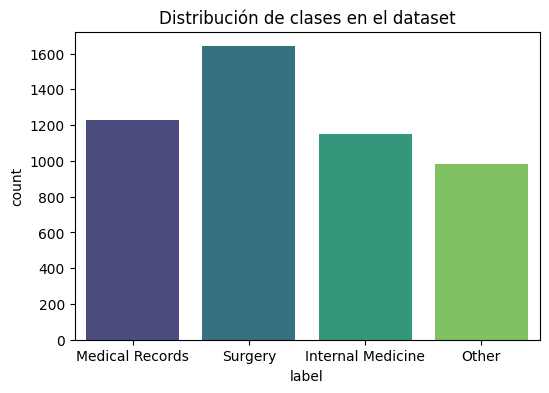


Conteo de etiquetas:
label
Surgery              1640
Medical Records      1228
Internal Medicine    1149
Other                 982
Name: count, dtype: int64

Porcentajes:
label
Surgery              32.806561
Medical Records      24.564913
Internal Medicine    22.984597
Other                19.643929
Name: proportion, dtype: float64


In [33]:
# ===============================
# 3. Distribución de clases
# ===============================
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df_med, palette="viridis")
plt.title("Distribución de clases en el dataset")
plt.show()

print("\nConteo de etiquetas:")
print(df_med["label"].value_counts())
print("\nPorcentajes:")
print(df_med["label"].value_counts(normalize=True) * 100)

Los resultados muestran un desbalance moderado en las clases, tal como el propósito de este apartado buscaba detectar.

- La clase '**Surgery**' es la más frecuente, con 1640 ejemplos (casi el 33% del total).

- La clase '**Other**' es la menos frecuente, con 982 ejemplos (cerca del 20%).

- '**Medical Records**' (24.6%) e '**Internal Medicine**' (22.9%) se sitúan en posiciones intermedias con 1228 y 1149 ejemplos respectivamente.

Esta desigualdad en la distribución implica que el modelo podría tender a aprender mejor las clases más frecuentes, mientras que las menos representadas podrían presentar mayor dificultad de reconocimiento. Por ello, es importante considerar técnicas de balanceo o métricas adecuadas para evitar que el predominio de ciertas etiquetas sesgue el rendimiento global del modelo.

Igualmente, podemos decir que todas las clases tienen una representación suficiente para aprender patrones, y que a pesar del desbalanceo, existe un equilibrio razonable que evita que una única clase domine el aprendizaje.

### **4. Longitud de las frases**

En este apartado calculamos cuántas palabras contiene cada texto y se representa la distribución de longitudes.

Así, podemos observar:

- Si los textos son largos o cortos.

- Cuánta variabilidad existe.

- Si el modelo necesitará manejar secuencias extensas.

- Detectar posibles valores atípicos (textos extremadamente largos o muy breves).

Debemos tener en cuenta que ambos datasets deben tener una longitud media de texto más o menos similar, para no hacer que el modelo aprenda esa característica como algo propio de un dominio u otro.

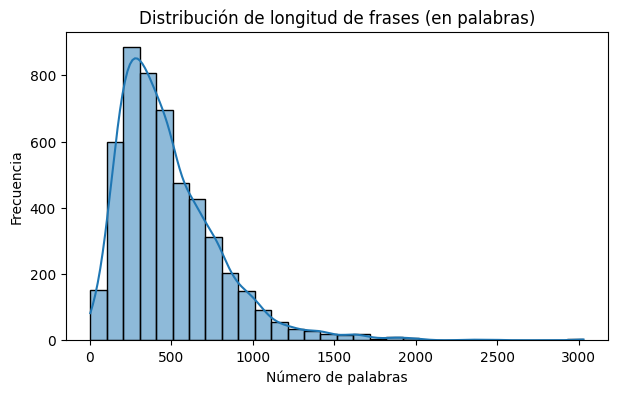


Estadísticas de longitud:
count    4999.000000
mean      482.303461
std       313.296265
min         2.000000
25%       260.000000
50%       414.000000
75%       632.000000
max      3029.000000
Name: n_words, dtype: float64


In [34]:
# ===============================
# 4. Longitud de las frases
# ===============================
df_med["n_words"] = df_med["text"].str.split().str.len()

plt.figure(figsize=(7,4))
sns.histplot(df_med["n_words"], bins=30, kde=True)
plt.title("Distribución de longitud de frases (en palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

print("\nEstadísticas de longitud:")
print(df_med["n_words"].describe())

Este dataset tiene un **promedio** de 482 palabras por texto, con una **desviación estándar** de aproximadamente 313 palabras. Esto indica que, aunque la mayoría de los textos se sitúan cerca de la media, existe una gran variabilidad en la longitud, con ejemplos mucho más cortos o mucho más largos que el promedio.

Podemos observar un rango muy amplio: hay textos extremadamente breves y otros muy extensos. La **mediana** (414 palabras) es menor que la media, lo que sugiere que unos pocos textos muy largos elevan el promedio, creando una distribución sesgada hacia la derecha, tal y como vemos en el gráfico.

**Implicaciones**:
- La gran variabilidad en la longitud significa que el modelo debe ser capaz de manejar secuencias de diferente tamaño.

- Los textos muy largos podrían requerir truncamiento o segmentación para ajustarse a limitaciones de memoria o tamaño de entrada del modelo.

- Los textos cortos podrían aportar poca información, por lo que el modelo deberá aprender a extraer características relevantes incluso de muestras pequeñas.

En reusmen, estas estadísticas muestran un dataset con diversidad suficiente para entrenar un modelo que capture patrones semánticos complejos, pero también presentan dificultades relacionados con la gestión de la longitud de las secuencias.

### **5. Distribución de longitud por clase**

En esta parte se analiza si la longitud del texto depende de la clase.
Se utilizan gráficos como boxplots y barras para observar:

- Diferencias en la media de longitud entre categorías.

- Dispersión.

- Presencia de outliers particulares por clase.

Esta información es importante porque, si las clases tienen longitudes muy distintas, el modelo podría aprender a clasificar solo por la extensión del texto.

/tmp/ipython-input-3583933636.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="n_words", data=df_med, palette="viridis")


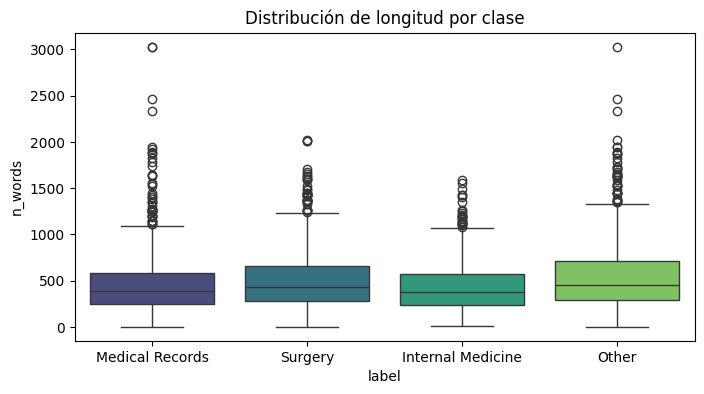

/tmp/ipython-input-3583933636.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=len_stats.index, y=len_stats["mean"], palette="viridis")


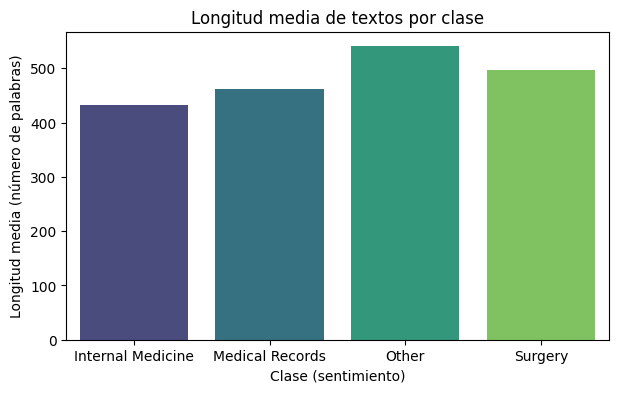

                    count        mean         std   min     25%    50%  \
label                                                                    
Internal Medicine  1149.0  433.296780  263.219808  10.0  237.00  373.0   
Medical Records    1228.0  462.402280  320.272082   2.0  251.75  392.5   
Other               982.0  540.500000  366.425644   3.0  293.00  454.5   
Surgery            1640.0  496.692683  299.023353   2.0  274.75  430.0   

                      75%     max  
label                              
Internal Medicine  570.00  1593.0  
Medical Records    588.00  3029.0  
Other              707.25  3029.0  
Surgery            661.00  2019.0  


In [35]:
# ===============================
# 5. Distribución de longitud por clase
# ===============================

plt.figure(figsize=(8,4))
sns.boxplot(x="label", y="n_words", data=df_med, palette="viridis")
plt.title("Distribución de longitud por clase")
plt.show()

len_stats = df_med.groupby("label")["n_words"].describe()

plt.figure(figsize=(7,4))
sns.barplot(x=len_stats.index, y=len_stats["mean"], palette="viridis")
plt.title("Longitud media de textos por clase")
plt.xlabel("Clase (sentimiento)")
plt.ylabel("Longitud media (número de palabras)")
plt.show()

print(len_stats)

Observamos como las clases **Other** y **Surgery** tienden a tener textos más largos, mientras que **Internal Medicine** y **Medical Records** contienen textos algo más cortos en promedio. La desviación estándar es considerable en todas las clases (entre 263 y 366), lo que refleja una gran variabilidad interna dentro de cada categoría.

Por otro lado, el mínimo de palabras por clase es muy bajo (2–10), lo que evidencia que hay **textos extremadamente cortos** en todas las categorías.

Además, los percentiles muestran que la mayoría de los textos se concentra en un rango intermedio, aunque hay **valores máximos muy altos** (hasta 3.029 palabras en Medical Records y Other), lo que provoca una distribución sesgada hacia textos muy largos en algunas clases.
Este hecho se puede evidenciar en los **boxplots**, los cuales revelan que todas las clases tienen numerosos **outliers** de textos largos.

**Implicaciones**:
- La variabilidad entre clases podría influir en la capacidad del modelo para generalizar: clases con textos muy largos pueden aportar más contexto y características, mientras que las más cortas podrían ser más difíciles de clasificar correctamente.

- Nuevamente concluimos que es importante considerar estrategias de preprocesamiento, como truncamiento o padding, para manejar diferencias de longitud y evitar que los textos más extensos dominen el aprendizaje.

Sin embargo, podemos decir que no hay una clara diferencia entre las longitudes medias de cada clase, por lo que no hay un excesivo riesgo de que el modelo clasifique en función a dicha característica.

### **6. Submuestreo de 4000 ejemplos**

Aquí se reduce el dataset de forma proporcional (submuestreo estratificado) para quedarnos con un total de 4000 ejemplos, con el objetivo de:

- Equilibrar el tamaño entre datasets, ya que el legal ocupará también 4000 ejemplos.

- Facilitar un entrenamiento más rápido.

- Evitar que un dominio domine al otro en la etapa combinada.

Después del submuestreo se recalcula la longitud y su distribución para comprobar que la muestra sigue siendo representativa.

/tmp/ipython-input-2095103068.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_med = df_med.groupby('label', group_keys=False).apply(


(4000, 3)


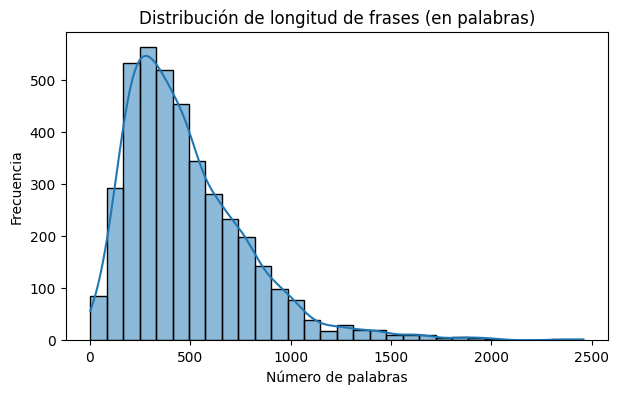


Estadísticas de longitud:
count    4000.000000
mean      481.454000
std       309.877354
min         2.000000
25%       259.000000
50%       413.500000
75%       633.000000
max      2460.000000
Name: n_words, dtype: float64


In [36]:
# ===============================
# 6. Submuestreo de 4000 ejemplos
# ===============================

tamaño_total = 4000
fraccion = tamaño_total / len(df_med)

df_med = df_med.groupby('label', group_keys=False).apply(
    lambda x: x.sample(frac=fraccion, random_state=5)
)

print(df_med.shape)

df_med["n_words"] = df_med["text"].str.split().str.len()

plt.figure(figsize=(7,4))
sns.histplot(df_med["n_words"], bins=30, kde=True)
plt.title("Distribución de longitud de frases (en palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

print("\nEstadísticas de longitud:")
print(df_med["n_words"].describe())

Al comparar las estadísticas de esta muestra (4000 ejemplos) con las del dataset original (4999 ejemplos de la sección 4), vemos que son casi idénticas:

- Original (4999): Media=482.3, Mediana=414.0, Std=313.3

- Muestra (4000): Media=481.4, Mediana=413.5, Std=309.9

**Implicación**: Este reusltado confirma que el submuestreo fue exitoso y que la muestra de 4000 registros es estadísticamente representativa del conjunto original en términos de longitud. El máximo se redujo (de 3029 a 2460), lo que indica que algunos de los outliers más extremos quedaron fuera, pero la distribución general se mantiene.

### **7. Palabras más frecuentes por clase**

En este bloque se limpian los textos (normalización básica, eliminación de stopwords) y se tokenizan, para posteriormente calcular qué palabras aparecen con mayor frecuencia dentro de cada categoría, y analizar su vocabulario característico.

In [37]:
# ===============================
# 7. Palabras más frecuentes por clase
# ===============================
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def limpiar_texto(texto):
    texto = texto.lower()  # Normalizamos el texto a minúsculas para facilitar el análisis posterior.
    texto = re.sub(r"[^a-zA-Z\s]", "", texto)
    texto = re.sub(r'\n+', '\n', texto)  # Reducimos saltos de línea múltiples a uno solo.
    texto = re.sub(r'[\t ]+', ' ', texto)  # Reemplazamos tabulaciones o múltiples espacios por un único espacio.
    texto = texto.strip()  # Quitamos espacios al inicio y al final.
    texto = re.sub(r'\n(?![A-Z])', ' ', texto)  # Unimos líneas si la siguiente no empieza por mayúscula (texto seguido).
    words = [w for w in texto.split() if w not in stop_words]
    return words

df_med["tokens"] = df_med["text"].apply(limpiar_texto)

def word_freq_por_clase(clase):
    palabras = [w for tokens in df_med[df_med["label"] == clase]["tokens"] for w in tokens]
    return Counter(palabras).most_common(15)

for clase in df_med["label"].unique():
    print(f"\nPalabras más comunes en clase '{clase}':")
    print(word_freq_por_clase(clase))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Palabras más comunes en clase 'Internal Medicine':
[('patient', 3860), ('history', 1896), ('left', 1895), ('right', 1868), ('normal', 1427), ('artery', 1160), ('mg', 1103), ('pain', 956), ('blood', 925), ('well', 890), ('procedure', 882), ('placed', 868), ('chest', 832), ('without', 733), ('coronary', 723)]

Palabras más comunes en clase 'Medical Records':
[('patient', 4437), ('history', 2976), ('normal', 2023), ('pain', 1639), ('right', 1565), ('left', 1500), ('mg', 1417), ('also', 1083), ('blood', 1001), ('without', 994), ('well', 985), ('time', 871), ('negative', 782), ('dr', 778), ('medical', 763)]

Palabras más comunes en clase 'Other':
[('patient', 3530), ('right', 2116), ('left', 1880), ('history', 1258), ('placed', 1159), ('pain', 1154), ('well', 1041), ('normal', 990), ('also', 841), ('time', 837), ('used', 715), ('anterior', 667), ('noted', 651), ('procedure', 649), ('performed', 639)]

Palabras más comunes en clase 'Surgery':
[('patient', 5735), ('placed', 3396), ('right', 

Aquí podemos identificar palabras frecuentes y  comunes del dominio en general: Términos como 'patient' (paciente), 'history' (historial), 'right' (derecho), 'left' (izquierdo), 'normal' y 'pain' (dolor) son muy frecuentes en todas las clases. Esto define el vocabulario general del dominio médico.

Por otro lado, podemos observar palabras distintivas a cada clase:

1. **Surgery**: Palabras frecuentes: patient, placed, right, left, procedure, incision, removed, performed, skin, room, diagnosis.

- **Observación**: Dominada por términos quirúrgicos y procedimentales (incision, removed, procedure, room), mostrando que los textos describen intervenciones, técnicas y entornos operatorios.

2. **Internal Medicine**: Palabras frecuentes: patient, history, left, right, artery, pain, blood, procedure.

- **Observación**: predominan términos relacionados con diagnósticos internos, anatomía y medidas clínicas (artery, mg, blood), reflejando que se centra en patologías no quirúrgicas.

3. **Medical Records**: Palabras frecuentes: patient, history, normal, pain, mg, blood, time, medical

- **Observación**: el vocabulario incluye términos más generales y administrativos (time, dr, medical).

4. **Other**: Palabras frecuentes: patient, right, left, placed, pain, procedure, used, noted, performed

- **Observación**: Los textos incluyen vocabulario variado, un mix de procedimientos y observaciones.

Todo esto sugiere que, aunque algunos términos comunes podrían inducir confusión, la presencia de palabras específicas por clase ayuda a que un modelo basado en embeddings aprenda representaciones diferenciadas y útiles para la tarea de clasificación.

### **8. Nubes de palabras**

Finalmente, se generan representaciones visuales donde las palabras más frecuentes aparecen más grandes, ofrecienco así una visualización más intuitiva y rápida del contenido de cada clase.

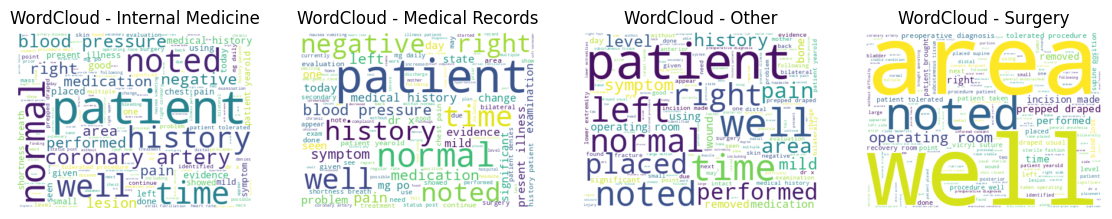

In [38]:
# ===============================
# 8. Nubes de palabras
# ===============================
plt.figure(figsize=(14,4))
for i, clase in enumerate(df_med["label"].unique()):
    plt.subplot(1,4,i+1)
    palabras = " ".join([" ".join(tokens) for tokens in df_med[df_med["label"]==clase]["tokens"]])
    wc = WordCloud(width=400, height=300, background_color="white").generate(palabras)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - {clase}")
plt.show()

Aquí observamos de forma más visual lo que habíamos explicado y desarrollado en el anterior apartado, con términos comunes a todas las clases, lo que permitirá al modelo aprender patrones generales del lenguaje médico pero también inducir a confusión para la segunda fase del entrenamiento (cabeza de clasificación); y por otro lado vemos vocabulario más específico y frecuente perteneciente a cada clase, proporcionando infromación discriminativa útil para esa clasificación.

# **Corpus legal**

### **1. Carga y preparación del dataset**

En primer lugar descargamos el dataset desde Kaggle y cargamos el archivo principal en un dataframe, renombrando las columnas relevantes para simplificar su uso. Después eliminamos campos que no aportan información al análisis, como el identificador del caso y el título. A continuación, definimos las etiquetas que queremos estudiar y filtramos el dataframe para quedarnos únicamente con las instancias cuya clase pertenece a ese conjunto objetivo. Esto nos permite trabajar con un subconjunto más limpio y centrado en las categorías de interés.



In [39]:
# ===============================
# 1. Cargamos dataset
# ===============================

path = kagglehub.dataset_download("shivamb/legal-citation-text-classification")

df = pd.read_csv(f"{path}/legal_text_classification.csv")
df.rename(columns={"case_text": "text", "case_outcome": "label"}, inplace=True)
df = df.drop(['case_id', 'case_title'], axis=1)
df.head()


Using Colab cache for faster access to the 'legal-citation-text-classification' dataset.


,label,text
0,cited,Ordinarily that discretion will be exercised s...
1,cited,The general principles governing the exercise ...
2,cited,Ordinarily that discretion will be exercised s...
3,cited,The general principles governing the exercise ...
4,cited,The preceding general principles inform the ex...


In [40]:
df['label'].unique()

array(['cited', 'applied', 'followed', 'referred to', 'related',
       'considered', 'discussed', 'distinguished', 'affirmed', 'approved'],
      dtype=object)

In [41]:
# 2. Definimos las etiquetas que nos interesan
target_labels = ['applied', 'considered', 'distinguished']

# 3. Filtrmos el dataset
df_filtered = df[df['label'].isin(target_labels)].copy()

df_filtered.head()

,label,text
8,applied,recent decision of the High Court in Australia...
34,considered,In Australian Securities and Investments Commi...
45,considered,The operation of s 80(1) of the TPA was canvas...
53,applied,Insofar as the argument is advanced based upon...
56,considered,"However, if authority were needed, the Full Co..."


### **2. Información general del dataset**

En esta parte del código realizamos una revisión inicial del dataset filtrado, mostrando su tamaño y algunos ejemplos aleatorios para verificar que los registros tienen el formato esperado. También comprobamos si existen valores nulos en cada columna y, en caso afirmativo, eliminamos las filas que los contienen para asegurar la calidad del conjunto de datos. Finalmente, volvemos a mostrar el tamaño del dataframe y la cantidad de valores nulos tras la limpieza, confirmando que el dataset queda depurado y listo para los siguientes pasos del análisis.

In [42]:
# ===============================
# 2. Información general
# ===============================
print("Tamaño total del dataset:", len(df_filtered))

print("\nEjemplo de registros:")
print(df_filtered.sample(5, random_state=42))

# --- Comprobación de valores nulos ---
print("\nValores nulos por columna:")
print(df_filtered.isnull().sum())

Tamaño total del dataset: 4768

Ejemplo de registros:
               label                                               text
5110         applied  second ground of appeal is that the appellant ...
11459  distinguished  As I said in Spriggs, argument by analogy must...
13324     considered  Optiver stressed that the question for it to d...
20814     considered  AWB submitted that the policy considerations t...
3372      considered  Section 177D(b) requires the decision-maker to...

Valores nulos por columna:
label     0
text     28
dtype: int64


In [43]:
# Borramos aquellos ejemplos nulos
num_filas_antes = len(df_filtered)
df_filtered = df_filtered.dropna()
num_filas_despues = len(df_filtered)

print(f"\nSe han borrado {num_filas_antes - num_filas_despues} filas que contenían valores nulos.")

# Verificación post-limpieza
print("\nTamaño total del dataset (DESPUÉS de borrar):", len(df_filtered))
print("\nValores nulos por columna (DESPUÉS de borrar):")
print(df_filtered.isnull().sum())


Se han borrado 28 filas que contenían valores nulos.

Tamaño total del dataset (DESPUÉS de borrar): 4740

Valores nulos por columna (DESPUÉS de borrar):
label    0
text     0
dtype: int64


El dataset contenía 4768 registros, pero se detectaron 28 textos nulos. Tras eliminarlos, el tamaño final quedó en 4740 filas, sin valores faltantes. Con esto, el conjunto de datos queda limpio y preparado para continuar con el análisis o entrenamiento.

### **3. Distribución de clases**

Se calcula y visualiza cuántos ejemplos pertenecen a cada categoría, además de mostrar sus porcentajes.
Con esto permitimos:


- Detectar posibles desbalances entre clases.


- Entender la importancia relativa de cada etiqueta.


- Anticipar problemas durante el entrenamiento, como clases con pocos ejemplos que puedan dificultar la generalización.



/tmp/ipython-input-2707469576.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df_filtered, palette="viridis")


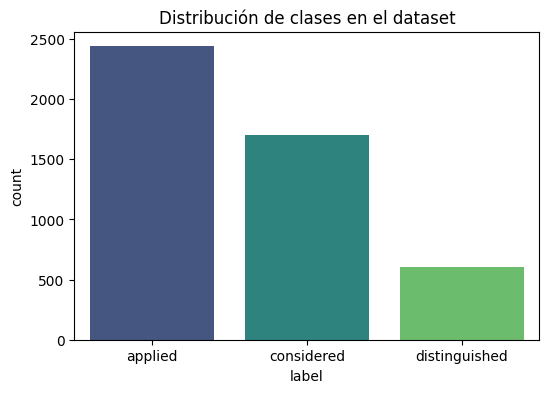


Conteo de etiquetas:
label
applied          2438
considered       1699
distinguished     603
Name: count, dtype: int64

Porcentajes:
label
applied          51.434599
considered       35.843882
distinguished    12.721519
Name: proportion, dtype: float64


In [44]:
# ===============================
# 3. Distribución de clases
# ===============================
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df_filtered, palette="viridis")
plt.title("Distribución de clases en el dataset")
plt.rcParams['text.usetex'] = False
plt.show()

print("\nConteo de etiquetas:")
print(df_filtered["label"].value_counts())
print("\nPorcentajes:")
print(df_filtered["label"].value_counts(normalize=True) * 100)

Los resultados muestran un desbalance moderado entre las clases, tal como el propósito de este apartado buscaba detectar.

- La clase 'applied' es la más frecuente, con 2438 ejemplos (alrededor del 51% del total).

- La clase 'distinguished' es la menos representada, con 603 ejemplos (cerca del 13%).

- Por su parte, 'considered' se sitúa en una posición intermedia con 1699 ejemplos (aproximadamente 36%).

Esta desigualdad en la distribución implica que el modelo podría aprender con mayor facilidad la clase dominante ('applied'), mientras que las clases menos frecuentes, especialmente 'distinguished', podrían resultar más difíciles de reconocer. Por ello, conviene considerar técnicas de balanceo o el uso de métricas adecuadas para evitar que el sesgo hacia la clase mayoritaria afecte al rendimiento global.

Aun así, todas las clases cuentan con una cantidad razonable de ejemplos, por lo que el modelo podrá aprender patrones significativos sin que una categoría quede totalmente infrarrepresentada.

### **4. Longitud de las frases**

En este apartado calculamos cuántas palabras contiene cada texto y representamos la distribución de longitudes.

Así, podemos observar:

- Si los textos son largos o cortos.

- Cuánta variabilidad existe en el tamaño de las frases.

- Si el modelo necesitará manejar secuencias extensas.

- La presencia de posibles valores atípicos (textos muy largos o muy breves).

Además, es importante considerar que distintos datasets deberían tener longitudes medias similares, para evitar que el modelo aprenda la extensión del texto como una característica propia de un dominio en lugar de centrarse en el contenido.

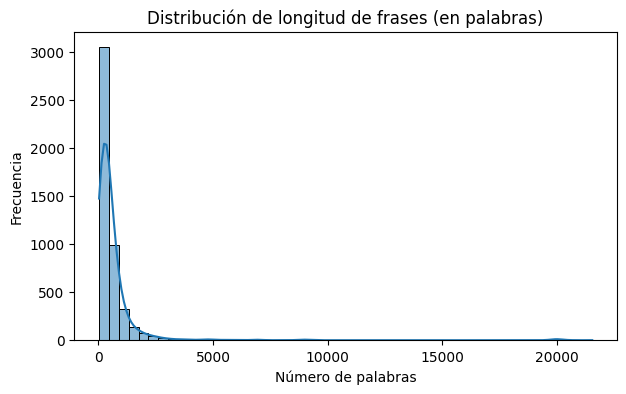


Estadísticas de longitud:
count     4740.000000
mean       622.113713
std       1462.134251
min         26.000000
25%        184.000000
50%        330.000000
75%        618.000000
max      21535.000000
Name: n_words, dtype: float64


In [45]:
# ===============================
# 4. Longitud de las frases
# ===============================
df_filtered["n_words"] = df_filtered["text"].str.split().str.len()

plt.figure(figsize=(7,4))
sns.histplot(df_filtered["n_words"], bins=50, kde=True)
plt.title("Distribución de longitud de frases (en palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

print("\nEstadísticas de longitud:")
print(df_filtered["n_words"].describe())

Este dataset tiene un promedio de 622 palabras por texto, con una desviación estándar de aproximadamente 1462 palabras. Esto indica que, aunque muchos textos se sitúan cerca de la media, existe una gran variabilidad en la longitud, con ejemplos mucho más cortos o extremadamente largos que el promedio.

Podemos observar un rango muy amplio: el texto más corto tiene 26 palabras y el más largo 21,535 palabras. La mediana (330 palabras) es considerablemente menor que la media, lo que sugiere que unos pocos textos muy extensos elevan el promedio, generando una distribución sesgada hacia la derecha, tal como se aprecia en el gráfico.

Implicaciones:

- La gran variabilidad en la longitud significa que el modelo debe manejar secuencias de diferente tamaño.

- Los textos muy largos podrían requerir truncamiento o segmentación para ajustarse a las limitaciones de memoria o al tamaño de entrada del modelo.

- Los textos cortos aportan poca información, por lo que el modelo deberá extraer características relevantes incluso de muestras pequeñas.

En resumen, estas estadísticas muestran un dataset con suficiente diversidad para entrenar un modelo capaz de capturar patrones semánticos complejos, pero también presentan desafíos relacionados con la gestión de la longitud de las secuencias.

### **5. Distribución de longitud por clase**



En esta parte se analiza si la longitud del texto depende de la clase. Se utilizan gráficos como boxplots y barras para observar:

- Diferencias en la media de longitud entre categorías.

- La dispersión de los textos dentro de cada clase.

- La presencia de outliers particulares por clase.

Esta información es importante porque, si las clases presentan longitudes muy distintas, el modelo podría aprender a clasificar únicamente basándose en la extensión del texto, en lugar de centrarse en el contenido semántico.

/tmp/ipython-input-1960368969.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="n_words", data=df_filtered, palette="viridis")


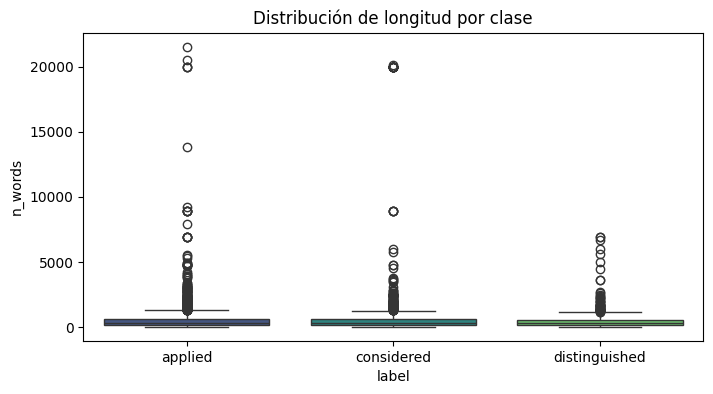

/tmp/ipython-input-1960368969.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=len_stats.index, y=len_stats["mean"], palette="viridis")


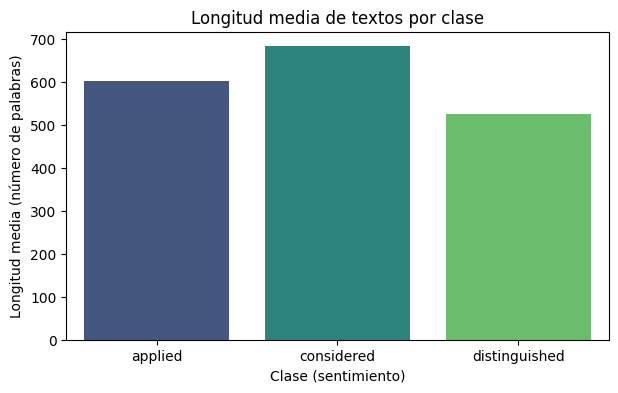

                count        mean          std   min    25%    50%    75%  \
label                                                                       
applied        2438.0  603.485234  1239.827060  26.0  180.0  329.0  619.5   
considered     1699.0  682.961742  1884.371861  34.0  188.5  342.0  623.0   
distinguished   603.0  525.986733   754.892353  29.0  177.0  313.0  580.0   

                   max  
label                   
applied        21535.0  
considered     20134.0  
distinguished   6924.0  


In [46]:
# ===============================
# 5. Distribución de longitud por clase
# ===============================

plt.figure(figsize=(8,4))
sns.boxplot(x="label", y="n_words", data=df_filtered, palette="viridis")
plt.title("Distribución de longitud por clase")
plt.show()

len_stats = df_filtered.groupby("label")["n_words"].describe()

plt.figure(figsize=(7,4))
sns.barplot(x=len_stats.index, y=len_stats["mean"], palette="viridis")
plt.title("Longitud media de textos por clase")
plt.xlabel("Clase (sentimiento)")
plt.ylabel("Longitud media (número de palabras)")
plt.show()

print(len_stats)

Observamos que las clases considered y applied tienden a tener textos más largos en promedio (682 y 603 palabras, respectivamente), mientras que distinguished contiene textos algo más cortos (526 palabras). La desviación estándar es considerable en todas las clases (entre 755 y 1884), lo que refleja una gran variabilidad interna dentro de cada categoría.

Por otro lado, el mínimo de palabras por clase es relativamente bajo (26–34), evidenciando que existen textos muy cortos en todas las categorías. Los percentiles muestran que la mayoría de los textos se concentra en un rango intermedio, aunque los valores máximos son extremadamente altos (hasta 21,535 palabras en applied y 20,134 en considered), lo que provoca una distribución sesgada hacia textos muy largos. Esto se refleja claramente en los boxplots, donde aparecen numerosos outliers de longitud elevada en todas las clases.

Implicaciones:

- La variabilidad entre clases podría influir en la capacidad del modelo para generalizar: textos muy largos aportan más contexto y características, mientras que los más cortos podrían ser más difíciles de clasificar.

- Es importante considerar estrategias de preprocesamiento, como truncamiento o padding, para manejar diferencias de longitud y evitar que los textos más extensos dominen el aprendizaje.

Sin embargo, no hay una diferencia marcada entre las longitudes medias de cada clase, por lo que el riesgo de que el modelo clasifique únicamente por esta característica es bajo.

### **6. Submuestreo de 4000 ejemplos**

En este apartado realizamos un submuestreo para quedarnos con 4,000 ejemplos, preservando la proporción de cada clase mediante muestreo aleatorio dentro de cada categoría.

Tras esto, se revisa la distribución de longitudes y las estadísticas descriptivas, asegurando que el dataset reducido sigue siendo representativo y manejable para el entrenamiento del modelo.

(4000, 3)


/tmp/ipython-input-2138187210.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered = df_filtered.groupby('label', group_keys=False).apply(


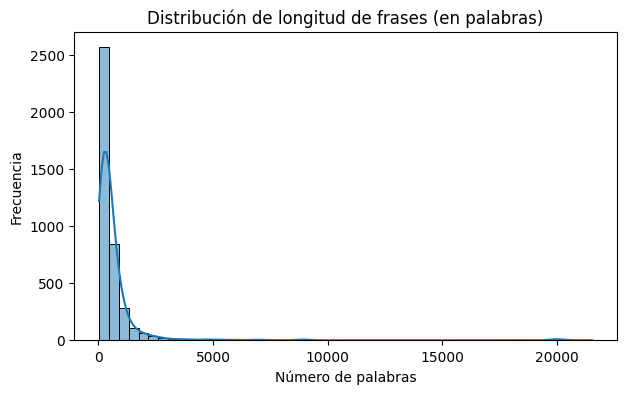


Estadísticas de longitud:
count     4000.000000
mean       631.595250
std       1509.096776
min         26.000000
25%        181.000000
50%        329.000000
75%        621.000000
max      21535.000000
Name: n_words, dtype: float64


In [48]:
# # ===============================
# # 7. Submuestreo de 4000 ejemplos
# # ===============================

# df es tu DataFrame, con una columna llamada 'clase'
tamaño_total = 4000  # número de ejemplos que quieres
fraccion = tamaño_total / len(df_filtered)

df_filtered = df_filtered.groupby('label', group_keys=False).apply(
    lambda x: x.sample(frac=fraccion, random_state=42)
)

print(df_filtered.shape)

plt.figure(figsize=(7,4))
sns.histplot(df_filtered["n_words"], bins=50, kde=True)
plt.title("Distribución de longitud de frases (en palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

print("\nEstadísticas de longitud:")
print(df_filtered["n_words"].describe())


Al comparar las estadísticas de esta muestra seleccionada (4000 ejemplos) con las del dataset original (4740 ejemplos), observamos una alta similitud en su distribución de longitud (Media y Desviación Típica casi idénticas), lo que confirma que la muestra es estadísticamente representativa y mantiene las propiedades del conjunto original.

- Original (4740): Media=622.1, Mediana=330.0, Std=1462.1

- Muestra (4000): Media=631.6, Mediana=329.0, Std=1509.1

Tras estos resultados llegamos a las mismas conclusiones que anteriormente: necesitamos un mecanismo de segmentación o truncamiento.

### **7. Palabras más frecuentes por clase**

En este bloque se limpian los textos (normalización básica, eliminación de stopwords) y se tokenizan, para posteriormente calcular qué palabras aparecen con mayor frecuencia dentro de cada categoría, y analizar su vocabulario característico.

In [49]:
# ===============================
# 8. Palabras más frecuentes por clase
# ===============================
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def limpiar_texto(texto):
    texto = texto.lower()  # Normalizamos el texto a minúsculas para facilitar el análisis posterior.
    texto = re.sub(r"[^a-zA-Z\s]", "", texto)
    texto = re.sub(r'\n+', '\n', texto)  # Reducimos saltos de línea múltiples a uno solo.
    texto = re.sub(r'[\t ]+', ' ', texto)  # Reemplazamos tabulaciones o múltiples espacios por un único espacio.
    texto = texto.strip()  # Quitamos espacios al inicio y al final.
    texto = re.sub(r'\n(?![A-Z])', ' ', texto)  # Unimos líneas si la siguiente no empieza por mayúscula (texto seguido).
    words = [w for w in texto.split() if w not in stop_words]
    return words

df_filtered["tokens"] = df_filtered["text"].apply(limpiar_texto)

def word_freq_por_clase(clase):
    palabras = [w for tokens in df_filtered[df_filtered["label"] == clase]["tokens"] for w in tokens]
    return Counter(palabras).most_common(15)

for clase in df_filtered["label"].unique():
    print(f"\nPalabras más comunes en clase '{clase}':")
    print(word_freq_por_clase(clase))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Palabras más comunes en clase 'applied':
[('v', 8246), ('court', 6003), ('ltd', 4396), ('j', 4087), ('act', 3692), ('would', 3538), ('case', 3468), ('pty', 2964), ('may', 2927), ('tribunal', 2867), ('evidence', 2828), ('made', 2742), ('whether', 2683), ('decision', 2632), ('clr', 2605)]

Palabras más comunes en clase 'considered':
[('v', 6195), ('court', 4452), ('j', 3724), ('legal', 3079), ('case', 2927), ('privilege', 2901), ('ltd', 2767), ('awb', 2534), ('act', 2513), ('evidence', 2450), ('advice', 2395), ('made', 2360), ('documents', 2315), ('would', 2268), ('may', 2151)]

Palabras más comunes en clase 'distinguished':
[('v', 1535), ('court', 1156), ('case', 1078), ('j', 836), ('act', 807), ('ltd', 747), ('would', 745), ('tribunal', 719), ('decision', 718), ('applicant', 658), ('application', 652), ('made', 621), ('mr', 556), ('evidence', 552), ('pty', 527)]


Aquí podemos identificar palabras frecuentes y comunes del dominio legal en general: Términos como 'v', 'court', 'case', 'act', 'j' y 'decision' aparecen muy frecuentemente en todas las clases. Esto define el vocabulario general del dominio jurídico.

Por otro lado, podemos observar palabras relativamente distintivas en cada clase:

- Applied: Palabras frecuentes incluyen ltd, tribunal, pty, clr, hca.
Observación: Predominan términos relacionados con la aplicación de decisiones y entidades legales específicas, mostrando que los textos describen casos en los que se aplican precedentes o leyes.

- Considered: Palabras frecuentes incluyen mr, evidence, would, made.
Observación: Se centra en el análisis y la consideración de pruebas y argumentos, reflejando textos más analíticos y evaluativos de los casos.

- Distinguished: Palabras frecuentes incluyen applicant, application, evidence, decision.
Observación: Los textos resaltan diferencias entre casos y la interpretación de solicitudes, mostrando un vocabulario más técnico en la distinción de precedentes y situaciones legales.

En resumen, aunque algunos términos comunes podrían generar cierta confusión entre clases, la presencia de palabras específicas por categoría permite que un modelo basado en embeddings aprenda representaciones diferenciadas y útiles para la tarea de clasificación de textos legales.

### **8. Nube de palabras**

Finalmente, se generan representaciones visuales donde las palabras más frecuentes aparecen más grandes, ofrecienco así una visualización más intuitiva y rápida del contenido de cada clase.

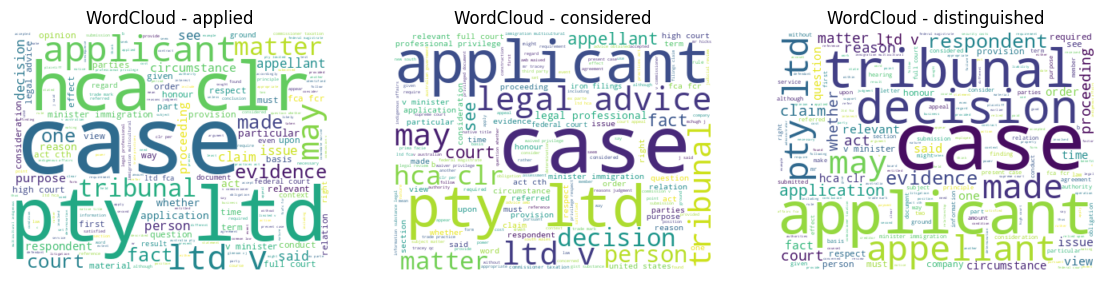

In [50]:
# ===============================
# 9. Nubes de palabras
# ===============================
plt.figure(figsize=(14,4))
for i, clase in enumerate(df_filtered["label"].unique()):
    plt.subplot(1,3,i+1)
    palabras = " ".join([" ".join(tokens) for tokens in df_filtered[df_filtered["label"]==clase]["tokens"]])
    wc = WordCloud(width=400, height=300, background_color="white").generate(palabras)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - {clase}")
plt.show()

Aquí observamos de forma más visual lo que habíamos explicado y desarrollado en el anterior apartado, con términos comunes a todas las clases, lo que permitirá al modelo aprender patrones generales del lenguaje legal pero también inducir a confusión para la segunda fase del entrenamiento (cabeza de clasificación); y por otro lado vemos vocabulario más específico y frecuente perteneciente a cada clase, proporcionando infromación discriminativa útil para esa clasificación.

### **Preparación de Datos: Estandarización, División Estratificada y Formateo**

En esta etapa inicial de procesamiento técnico, el objetivo es consolidar la estructura de los conjuntos de datos y establecer las bases para una evaluación robusta del modelo. En primer lugar, se asegura la estandarización de las columnas en ambos dominios (médico y legal). Es imperativo que las variables de entrada se denominen text y las de salida label, garantizando así que el pipeline de tokenización y entrenamiento sea uniforme para todas las muestras, independientemente de su origen.

Posteriormente, se lleva a cabo la división estratificada de los datos, destinando un 80% de las muestras al entrenamiento y un 20% a la evaluación externa. La elección de un muestreo estratificado es fundamental en este escenario de clasificación multidominio; esta técnica asegura que la proporción de clases originales se mantenga constante tanto en el conjunto de entrenamiento como en el de test, evitando que el modelo sea evaluado sobre distribuciones de etiquetas sesgadas que no representen fielmente la realidad del corpus.

Finalmente, los datos se transforman de estructuras Pandas DataFrames a objetos DatasetDict de la librería Hugging Face. Esta conversión no es solo una cuestión de formato, sino una optimización de rendimiento necesaria. Los objetos de tipo Dataset permiten una gestión de memoria más eficiente y son el estándar de entrada para las funciones de tokenización dinámica y los entrenadores de la librería Transformers que se emplearán en las fases de pre-entrenamiento adaptativo (MLM) y clasificación supervisada.

In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict, concatenate_datasets

# ==========================================
# 1. PREPARACIÓN INICIAL Y SPLIT
# ==========================================

# Renombrar el dataframe legal para trabajar cómodamente
df_legal = df_filtered.copy()

# Verificamos que las columnas se llamen 'text' y 'label' en ambos
print(f"Columnas Med: {df_med.columns}")
print(f"Columnas Legal: {df_legal.columns}")

# División Estratificada (80% Train, 20% Test)
# Mantiene la proporción de clases en el split
train_med, test_med = train_test_split(df_med, test_size=0.2, stratify=df_med['label'], random_state=42)
train_leg, test_leg = train_test_split(df_legal, test_size=0.2, stratify=df_legal['label'], random_state=42)

print(f"Train Médico: {len(train_med)} | Test Médico: {len(test_med)}")
print(f"Train Legal: {len(train_leg)} | Test Legal: {len(test_leg)}")

# Convertimos a formato Dataset de Hugging Face para facilitar el procesamiento
ds_med = DatasetDict({
    'train': Dataset.from_pandas(train_med),
    'test': Dataset.from_pandas(test_med)
})
ds_leg = DatasetDict({
    'train': Dataset.from_pandas(train_leg),
    'test': Dataset.from_pandas(test_leg)
})

Columnas Med: Index(['text', 'label', 'n_words', 'tokens'], dtype='object')
Columnas Legal: Index(['label', 'text', 'n_words', 'tokens'], dtype='object')
Train Médico: 3200 | Test Médico: 800
Train Legal: 3200 | Test Legal: 800


### **Configuración del Modelo y Estrategia de Segmentación Dinámica (Chunking)**

En esta celda se establece el núcleo del procesamiento lingüístico del proyecto mediante la selección del modelo base y la implementación de una estrategia avanzada de gestión de secuencias largas. Se ha optado por la versión **bert-base-uncased**, un modelo de arquitectura *encoder* bidireccional pre-entrenado específicamente para el idioma inglés. Esta elección responde a la necesidad de capturar contextos complejos en ambas direcciones, algo vital para la terminología técnica médico-legal, manteniendo un equilibrio eficiente entre capacidad de representación (110M de parámetros) y consumo de recursos en hardware limitado.

Debido a la restricción física de BERT, que impone un límite máximo de **512 tokens por secuencia**, resulta inviable procesar documentos extensos (especialmente en el ámbito legal) mediante un truncamiento simple, ya que se perdería información crítica ubicada al final de los archivos. Para mitigar este problema, se define la función chunk_examples, la cual implementa una **estrategia de ventana deslizante**. En lugar de recortar el texto, el algoritmo divide cada documento en fragmentos o *chunks* de 510 tokens, reservando los dos espacios restantes para la inyección manual de los tokens especiales obligatorios ([CLS] y [SEP]).

La configuración incluye un **solapamiento (*overlap*) de 50 tokens** y un avance (*stride*) de 460 tokens. El objetivo de este solapamiento es garantizar la continuidad semántica, evitando que una frase sea cortada de forma abrupta en el límite de un bloque y asegurando que el contexto de frontera se preserve en al menos uno de los fragmentos adyacentes. Finalmente, se aplica un filtro de ruido para descartar cualquier fragmento inferior a 30 tokens, asumiendo que secuencias tan breves carecen de la riqueza léxica necesaria para una clasificación precisa y solo introducirían inestabilidad durante el entrenamiento.

In [52]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# CONFIGURACIÓN PARA TEXTOS EN INGLÉS

# Usamos el BERT original de Google (versión minúsculas, estándar para inglés)
model_id = "bert-base-uncased"

# Cargamos el tokenizador de BERT en inglés
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Función de Chunking (Adaptada para el límite de 512 tokens de BERT)
def chunk_examples(examples):
    # Tokenizamos sin truncar primero
    # BERT en inglés usa WordPiece
    inputs = tokenizer(examples["text"], truncation=False, padding=False, add_special_tokens=False)

    # Dejamos espacio para [CLS] al inicio y [SEP] al final (512 - 2 = 510)
    chunk_size = 510
    overlap = 50
    stride = chunk_size - overlap

    new_input_ids = []
    new_labels = []

    for input_ids, label in zip(inputs["input_ids"], examples["label"]):
        # Ventana deslizante sobre los tokens
        for i in range(0, len(input_ids), stride):
            chunk = input_ids[i : i + chunk_size]

            # Filtramos chunks demasiado pequeños que pueden ser ruido
            if len(chunk) > 30:
                # BERT necesita añadir los tokens especiales manualmente al hacer chunking así
                final_chunk = tokenizer.build_inputs_with_special_tokens(chunk)
                new_input_ids.append(final_chunk)
                new_labels.append(label)

    return {
        "input_ids": new_input_ids,
        "labels": new_labels
    }

print(f"Modelo cargado: {model_id} (Inglés)")

Modelo cargado: bert-base-uncased (Inglés)


### **Ejecución de la Segmentación y Construcción del Corpus Generalista**

En esta celda se procede a la ejecución material de la estrategia de segmentación (*chunking*) diseñada anteriormente, aplicando la función mapeada sobre la totalidad de los conjuntos de datos médico y legal. La operación se realiza utilizando el parámetro `batched=True`, una técnica de optimización que permite procesar múltiples documentos de forma simultánea, acelerando drásticamente el tiempo de cómputo y optimizando el uso de la memoria caché durante la tokenización. Al finalizar el mapeo, se eliminan las columnas originales del dataset para conservar únicamente las estructuras vectoriales (`input_ids` y `labels`) requeridas por el modelo.

Posteriormente, se establece la base para la comparación experimental mediante la creación del **Dataset Generalista**. Utilizando la función `concatenate_datasets`, se fusionan los fragmentos de entrenamiento de ambos dominios en un único objeto de datos unificado. Este paso es crítico, ya que genera el corpus híbrido necesario para entrenar el adaptador generalista, el cual servirá como línea base (*baseline*) para contrastar su rendimiento frente a la estrategia de fusión de expertos individuales.

Finalmente, el resumen estadístico de la celda permite validar la eficacia del *chunking* como mecanismo de balanceo. Aunque los documentos originales presentaban longitudes y complejidades muy dispares, la transformación en fragmentos normalizados de 512 tokens resulta en una distribución de carga casi simétrica para el entrenamiento: aproximadamente 6,634 fragmentos para el dominio médico y 6,943 para el legal. Esta paridad en el número de muestras asegura que el modelo generalista reciba una señal de aprendizaje equilibrada, evitando que el volumen de texto de un dominio predomine sobre el otro durante la actualización de los pesos.

In [53]:
from datasets import concatenate_datasets

# 1. Aplicamos la función de chunking
# batched=True acelera el proceso drásticamente
print("Procesando chunks para el dataset Médico...")
tokenized_med = ds_med.map(chunk_examples, batched=True, remove_columns=ds_med['train'].column_names)

print("Procesando chunks para el dataset Legal...")
tokenized_leg = ds_leg.map(chunk_examples, batched=True, remove_columns=ds_leg['train'].column_names)

# 2. Creamos el Dataset Generalista (Unión de ambos TRAIN)
# Solo unimos el train, el test se queda separado para evaluar luego
tokenized_general_train = concatenate_datasets([tokenized_med['train'], tokenized_leg['train']])

print(f"\nResumen de datos tokenizados para entrenamiento:")
print(f" - Chunks Médicos: {len(tokenized_med['train'])}")
print(f" - Chunks Legales: {len(tokenized_leg['train'])}")
print(f" - Chunks Generalista (Mix): {len(tokenized_general_train)}")

Procesando chunks para el dataset Médico...


Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1557 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Procesando chunks para el dataset Legal...


Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]


Resumen de datos tokenizados para entrenamiento:
 - Chunks Médicos: 6634
 - Chunks Legales: 6943
 - Chunks Generalista (Mix): 13577


### **Configuración y Ejecución del Pre-entrenamiento Adaptativo (MLM) con LoRA**

En esta celda se implementa la primera fase crítica del proyecto: la **Adaptación al Dominio (DAPT)** mediante el modelado de lenguaje enmascarado (MLM). El objetivo fundamental de esta etapa es que el modelo base adquiera un conocimiento lingüístico profundo y específico de los dominios técnico-médico y jurídico antes de abordar la tarea final de clasificación. Para ello, se configura un `DataCollatorForLanguageModeling` que aplica un enmascaramiento dinámico del 15% de los tokens en cada época. Esta estrategia de auto-supervisión obliga al modelo a reconstruir el texto basándose en el contexto semántico circundante, permitiendo que los *embeddings* se realineen y capturen las relaciones técnicas propias de cada campo profesional de una manera mucho más exhaustiva que un ajuste supervisado directo.

Dadas las restricciones de hardware y la búsqueda de una arquitectura escalable, se emplea la técnica **LoRA (Low-Rank Adaptation)** para este proceso. Se ha definido una configuración con un rango  y un factor de escala , aplicada específicamente a los módulos de atención *Query* y *Value* de BERT. Al congelar los 110 millones de parámetros del modelo base y actualizar únicamente estas matrices de bajo rango, se reduce el volumen de parámetros entrenables a menos del 1% del total. Esto no solo optimiza el uso de memoria en la GPU NVIDIA T4, sino que permite generar "expertos" modulares en forma de adaptadores livianos que pueden ser almacenados y fusionados con facilidad.

Finalmente, la función `train_domain_model` automatiza el ciclo de entrenamiento y la recolección de métricas de eficiencia para los tres escenarios propuestos: el **experto médico**, el **experto legal** y el **modelo generalista** que servirá como línea base (*baseline*). Durante la ejecución, se monitoriza con precisión el tiempo de cómputo real y el pico de memoria VRAM asignada, permitiendo realizar una comparativa de costes computacionales. Los tres adaptadores resultantes constituyen los bloques de construcción fundamentales para proceder a la fase de fusión y validar la hipótesis sobre la superioridad de los modelos especializados combinados frente al entrenamiento conjunto tradicional.

In [55]:
from transformers import AutoModelForMaskedLM, DataCollatorForLanguageModeling, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType
import time
import torch

# CONFIGURACIÓN DEL ENTRENAMIENTO (MLM)

# Usamos DataCollatorForLanguageModeling para tapar palabras aleatoriamente (15%)
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15)

# Configuración LoRA específica para BERT
peft_config = LoraConfig(
    task_type=TaskType.FEATURE_EXTRACTION,
    inference_mode=False,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "value"]
)

def train_domain_model(dataset, output_name):
    print(f"\n Iniciando entrenamiento experto: {output_name}")

    # Eliminamos la columna 'labels' (clase) y 'domain' si existe.
    # Para MLM solo queremos 'input_ids' y 'attention_mask' (si existe).
    # El DataCollator creará las 'labels' de predicción automáticamente.
    cols_to_remove = [col for col in dataset.column_names if col not in ["input_ids", "attention_mask"]]
    dataset_clean = dataset.remove_columns(cols_to_remove)

    print(f"Columnas usadas para entrenar: {dataset_clean.column_names}")

    # Cargar modelo base limpio
    model = AutoModelForMaskedLM.from_pretrained(model_id)

    # Aplicar LoRA
    model = get_peft_model(model, peft_config)

    training_args = TrainingArguments(
        output_dir=f"./results/{output_name}",
        per_device_train_batch_size=16,
        num_train_epochs=3,
        learning_rate=1e-4,
        weight_decay=0.01,
        fp16=True, # Importante: usa GPU
        logging_steps=50,
        save_strategy="epoch",
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset_clean, # Usamos el dataset limpio
        data_collator=data_collator,
    )

    # --- BLOQUE DE MEDICIÓN ---
    torch.cuda.reset_peak_memory_stats() # Reseteamos contador de VRAM
    start_time = time.time()

    # Entrenamos y capturamos el resultado
    train_result = trainer.train()

    end_time = time.time()
    pico_memoria = torch.cuda.max_memory_allocated() / (1024 ** 3) # Convertir a GB
    total_time = end_time - start_time
    # --------------------------

    # Guardamos solo el adaptador LoRA
    save_path = f"./models/{output_name}_lora"
    model.save_pretrained(save_path)
    print(f"Adaptador guardado en: {save_path}")

    # REPORTAMOS MÉTRICAS DE COSTE
    metrics = train_result.metrics
    metrics["peak_memory_gb"] = pico_memoria
    metrics["wall_clock_time"] = total_time

    print("\nREPORTE DE COSTE COMPUTACIONAL")
    print(f"   - Tiempo Total:   {total_time/60:.2f} minutos")
    print(f"   - Memoria Pico:   {pico_memoria:.2f} GB")
    print("==========================================\n")

    return save_path


# EJECUCIÓN DE LOS 3 ENTRENAMIENTOS

# 1. Entrenar Experto Médico
path_lora_med = train_domain_model(tokenized_med['train'], "experto_medico")

# 2. Entrenar Experto Legal
path_lora_leg = train_domain_model(tokenized_leg['train'], "experto_legal")

# 3. Entrenar Modelo Generalista (Baseline)
path_lora_gen = train_domain_model(tokenized_general_train, "modelo_generalista")


 Iniciando entrenamiento experto: experto_medico
Columnas usadas para entrenar: ['input_ids']


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Step,Training Loss
50,2.410100
100,2.273300
150,2.277000
200,2.222400
250,2.169200
300,2.172700
350,2.145400
400,2.153600
450,2.139800
500,2.145200


Adaptador guardado en: ./models/experto_medico_lora

REPORTE DE COSTE COMPUTACIONAL
   - Tiempo Total:   8.76 minutos
   - Memoria Pico:   6.26 GB


 Iniciando entrenamiento experto: experto_legal
Columnas usadas para entrenar: ['input_ids']


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Step,Training Loss
50,2.351500
100,2.253000
150,2.201200
200,2.218900
250,2.142100
300,2.147500
350,2.110200
400,2.154500
450,2.134600
500,2.120200


Adaptador guardado en: ./models/experto_legal_lora

REPORTE DE COSTE COMPUTACIONAL
   - Tiempo Total:   9.18 minutos
   - Memoria Pico:   6.25 GB


 Iniciando entrenamiento experto: modelo_generalista
Columnas usadas para entrenar: ['input_ids']


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Step,Training Loss
50,2.392300
100,2.297000
150,2.227000
200,2.228700
250,2.197900
300,2.177100
350,2.200800
400,2.172700
450,2.206500
500,2.158800


Adaptador guardado en: ./models/modelo_generalista_lora

REPORTE DE COSTE COMPUTACIONAL
   - Tiempo Total:   17.91 minutos
   - Memoria Pico:   6.26 GB



### **Análisis del Espacio Latente mediante Proyecciones T-SNE**

En esta celda se implementa una herramienta de diagnóstico crítico para el proyecto: la visualización del espacio latente. El objetivo fundamental es realizar un "sanity check" que permita comprender cómo los adaptadores LoRA han reconfigurado las representaciones internas de BERT tras la fase de pre-entrenamiento adaptativo (MLM). Mediante esta técnica, podemos verificar visualmente si el modelo ha logrado desarrollar una sensibilidad suficiente para distinguir las fronteras semánticas entre el dominio médico y el legal antes de proceder a la tarea de clasificación supervisada.

El proceso técnico comienza con la **reconstrucción de muestras de texto** a partir de los identificadores numéricos del conjunto de prueba, utilizando para ello la función de decodificación del tokenizador. Una vez recuperada la información textual, se extraen los *embeddings* de alta dimensión generados por el token especial **`[CLS]`** (ubicado en el índice 0 de la última capa oculta), el cual encapsula la representación semántica global de cada secuencia. Este procedimiento se repite para los tres adaptadores generados (médico, legal y generalista), permitiendo una comparativa directa de cómo cada experto organiza la información en su espacio vectorial.

Para hacer interpretable esta información de alta dimensionalidad, se aplica el algoritmo **T-SNE (t-Distributed Stochastic Neighbor Embedding)**, el cual reduce los vectores a un plano bidimensional preservando las relaciones de proximidad local. La visualización resultante permite identificar la formación de *clusters* diferenciados: una clara separación entre los puntos azules (médicos) y rojos (legales) indica que el modelo ha capturado con éxito las disparidades léxicas y sintácticas de ambos campos. Este análisis es vital para validar nuestra hipótesis inicial, ya que la cohesión y el aislamiento de estos grupos en el espacio latente suelen correlacionar directamente con la precisión final del clasificador.

Reconstruyendo textos para visualización...
Generando embeddings para: ./models/modelo_generalista_lora...


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


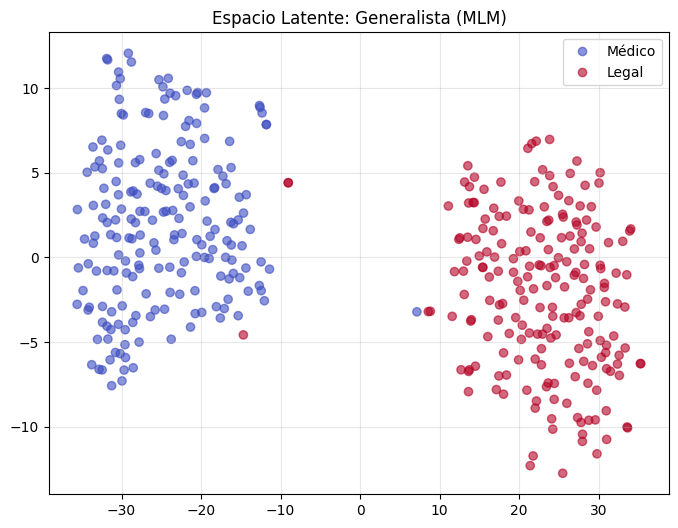

Generando embeddings para: ./models/experto_medico_lora...


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


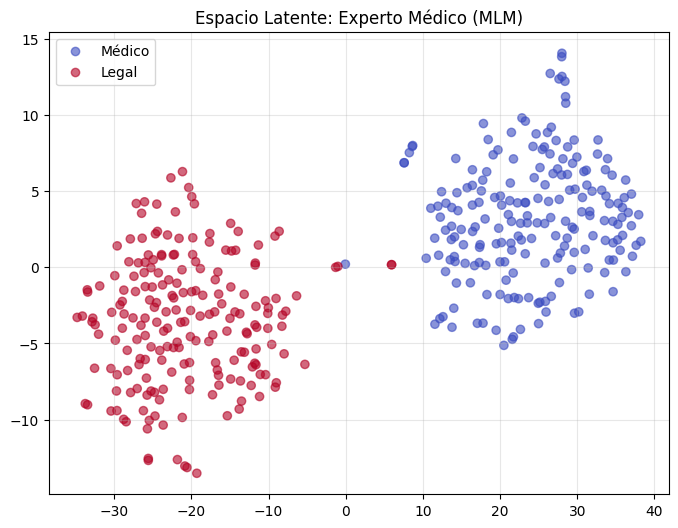

Generando embeddings para: ./models/experto_legal_lora...


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


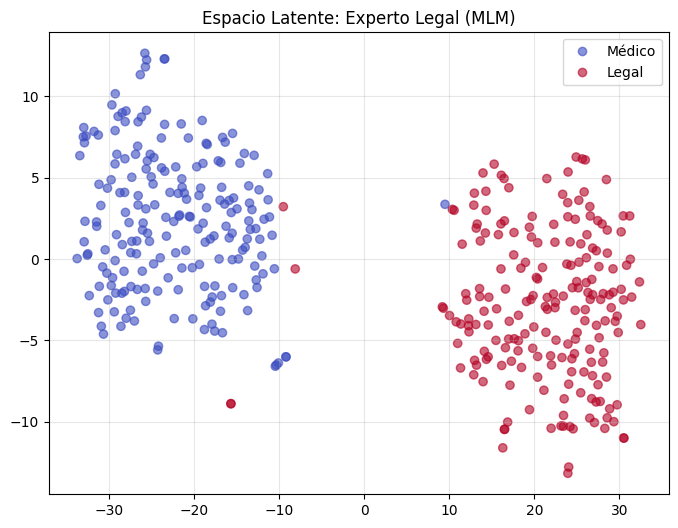

In [56]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from peft import PeftModel
from transformers import AutoModelForMaskedLM, AutoTokenizer

# ==========================================
# ANÁLISIS VISUAL DE EMBEDDINGS (CORREGIDO)
# ==========================================

# 1. Recuperamos el texto DECODIFICANDO los IDs numéricos
# Como borramos la columna 'text', la reconstruimos desde los input_ids
print("Reconstruyendo textos para visualización...")

# Seleccionamos 200 ejemplos
sample_med = tokenized_med['test'].select(range(200))
sample_leg = tokenized_leg['test'].select(range(200))

# Decodificamos (convertimos números a texto otra vez)
texts_med = tokenizer.batch_decode(sample_med['input_ids'], skip_special_tokens=True)
texts_leg = tokenizer.batch_decode(sample_leg['input_ids'], skip_special_tokens=True)

all_texts = texts_med + texts_leg

# Etiquetas para pintar: 0=Médico (Azul), 1=Legal (Rojo)
labels_viz = [0] * len(texts_med) + [1] * len(texts_leg)

def get_model_embeddings(base_model_id, lora_path, texts):
    print(f"Generando embeddings para: {lora_path}...")

    # Cargamos modelo base
    model = AutoModelForMaskedLM.from_pretrained(base_model_id)

    # Intentamos cargar el adaptador. Si falla (ej. ruta incorrecta), avisamos.
    try:
        model = PeftModel.from_pretrained(model, lora_path)
    except Exception as e:
        print(f"Error cargando LoRA en {lora_path}: {e}")
        return None

    model.to("cuda") # A GPU
    model.eval()

    tokenizer = AutoTokenizer.from_pretrained(base_model_id)
    embeddings = []

    # Procesamos por lotes
    batch_size = 32
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        # Re-tokenizamos para extraer el embedding limpio del token [CLS]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to("cuda")

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            # Embedding del token [CLS] (primer token, índice 0)
            cls_emb = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
            embeddings.append(cls_emb)

    return np.concatenate(embeddings)

def plot_tsne(embeddings, labels, title):
    # t-SNE para reducir a 2D
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    emb_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    # Pintamos: Azul (0) para Médico, Rojo (1) para Legal
    scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, cmap='coolwarm', alpha=0.6)
    plt.title(title)
    # Leyenda manual
    plt.legend(handles=scatter.legend_elements()[0], labels=["Médico", "Legal"])
    plt.grid(True, alpha=0.3)
    plt.show()

# --- EJECUTAMOS EL ANÁLISIS ---

models_to_check = {
    "Generalista (MLM)": "./models/modelo_generalista_lora",
    "Experto Médico (MLM)": "./models/experto_medico_lora",
    "Experto Legal (MLM)": "./models/experto_legal_lora"
}

for name, path in models_to_check.items():
    embs = get_model_embeddings("bert-base-uncased", path, all_texts)
    if embs is not None:
        plot_tsne(embs, labels_viz, f"Espacio Latente: {name}")

### **Normalización, Unificación de Etiquetas y Creación del Dataset Multitarea**

En esta celda se aborda uno de los desafíos críticos de la clasificación multidominio: la gestión de un espacio de etiquetas heterogéneo. Originalmente, los conjuntos de datos médico y legal operan con índices numéricos superpuestos (0-3 y 0-2, respectivamente), lo que generaría una colisión semántica insalvable si se entrenaran conjuntamente sin intervención. Para resolverlo, se implementa una estrategia de **Normalización y Desplazamiento de Etiquetas (Label Shifting)**.

Primero, se asegura que todas las etiquetas sean tratadas como valores enteros mediante mapeos específicos para cada dominio. Posteriormente, para el modelo multitarea, se aplica un desplazamiento de +4 a las etiquetas del dominio legal. Esta operación transforma el problema en una clasificación única de **7 clases** (0-3 médicas y 4-6 legales), permitiendo que el modelo aprenda a discriminar no solo entre categorías individuales, sino también entre la naturaleza técnica de ambos dominios de forma implícita.

Finalmente, se procede a la creación del **Dataset Multitarea** mediante la concatenación de los corpus médico (normalizado) y legal (desplazado). El conjunto de entrenamiento se somete a un proceso de barajado aleatorio (*shuffle*) para garantizar que, durante el descenso de gradiente, el modelo reciba muestras de ambos dominios de manera intercalada. Esta mezcla es vital para evitar sesgos de orden y asegurar que la red desarrolle representaciones robustas capaces de manejar la diversidad léxica y estructural del espacio combinado médico-legal.

In [57]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
from datasets import concatenate_datasets
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# ==========================================
# 1. NORMALIZACIÓN Y UNIFICACIÓN DE ETIQUETAS
# ==========================================

# Definimos los mapeos para asegurar que trabajamos con INTEGERS
med_mapping = {'Records': 0, 'Other': 1, 'Internal': 2, 'Surgery': 3}
leg_mapping = {'applied': 0, 'considered': 1, 'distinguished': 2}

def fix_med_labels(example):
    val = example["labels"]
    if isinstance(val, str): val = med_mapping.get(val, 0)
    example["labels"] = int(val)
    return example

def fix_leg_labels(example):
    val = example["labels"]
    if isinstance(val, str): val = leg_mapping.get(val, 0)
    example["labels"] = int(val)
    return example

def shift_leg_labels(example):
    # Esta función es SOLO para el modelo Multitarea (0,1,2 -> 4,5,6)
    val = example["labels"]
    if isinstance(val, str): val = leg_mapping.get(val, 0)
    example["labels"] = int(val) + 4
    return example

print("Normalizando datasets...")
# Datasets para Expertos (Etiquetas originales 0-N)
ds_med_expert = tokenized_med.map(fix_med_labels)
ds_leg_expert = tokenized_leg.map(fix_leg_labels)

# Datasets para Multitarea (Legal desplazado a 4-6)
ds_leg_shifted = tokenized_leg.map(shift_leg_labels)

train_multitask = concatenate_datasets([ds_med_expert['train'], ds_leg_shifted['train']]).shuffle(seed=42)
test_multitask = concatenate_datasets([ds_med_expert['test'], ds_leg_shifted['test']])

Normalizando datasets...


Map:   0%|          | 0/6634 [00:00<?, ? examples/s]

Map:   0%|          | 0/1692 [00:00<?, ? examples/s]

Map:   0%|          | 0/6943 [00:00<?, ? examples/s]

Map:   0%|          | 0/1879 [00:00<?, ? examples/s]

Map:   0%|          | 0/6943 [00:00<?, ? examples/s]

Map:   0%|          | 0/1879 [00:00<?, ? examples/s]

### **Fusión de Adaptadores LoRA y Entrenamiento de Clasificadores Multidominio**

Esta celda constituye el núcleo experimental del proyecto, donde se materializa la integración de conocimientos especializados y se ejecuta la tarea final de clasificación supervisada. El proceso comienza con la **fusión matemática de los adaptadores** mediante la función `fuse_lora_weights`. Esta técnica aplica una combinación lineal aritmética de los pesos de los expertos médico y legal, utilizando un coeficiente  que asume una importancia equitativa para ambos dominios. El propósito de esta fase es consolidar en un único adaptador liviano las representaciones semánticas ricas adquiridas durante la etapa de pre-entrenamiento adaptativo (MLM), permitiendo que el sistema final posea una base de conocimiento bilingüe (médico-legal) antes de afrontar la discriminación de clases.

Posteriormente, se define la infraestructura para el **ajuste fino supervisado (SFT)** a través de la función `train_classifier`. En esta etapa, el modelo base BERT se inicializa para una tarea de clasificación de secuencias con 7 etiquetas, incorporando una **cabeza de clasificación** (capa densa final) inicializada aleatoriamente. Un aspecto técnico fundamental es la configuración del adaptador como entrenable (`is_trainable=True`) y la habilitación explícita de gradientes para el clasificador; esto permite que, durante la propagación hacia atrás, el modelo no solo aprenda a asignar etiquetas, sino que también reajuste sutilmente los pesos fusionados para alinearlos con la tarea discriminativa específica de cada categoría.

Para garantizar la validez científica de la comparativa entre la estrategia de **Fusión** y el **Modelo Generalista**, el proceso incorpora protocolos estrictos de **reproducibilidad y medición de costes**. Se implementa un control de semillas (`seed` y `data_seed`) para asegurar que el barajado de datos y la inicialización de pesos sean idénticos en ambos experimentos. Asimismo, se integra un bloque de monitorización que captura el tiempo de cómputo real y el pico de memoria VRAM (vía `torch.cuda.max_memory_allocated`), lo que resulta crítico para validar la eficiencia de la arquitectura PEFT en hardware limitado como la GPU T4.

Finalmente, tras completar las épocas de entrenamiento, se ejecuta la operación de **consolidación (*Merge and Unload*)**. Este paso multiplica las matrices de bajo rango de LoRA y las suma permanentemente a los pesos del modelo base, generando un modelo BERT estándar de 110 millones de parámetros listo para producción. Este procedimiento elimina cualquier latencia computacional asociada a los adaptadores en tiempo de ejecución, entregando un modelo final autónomo que integra el conocimiento experto de forma nativa en su arquitectura.

In [59]:
# ==========================================
# 2. CONFIGURACIÓN DEL ENTRENAMIENTO
# ==========================================

import torch
from peft import PeftModel
import os
from safetensors.torch import load_file, save_file
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import time

# ==========================================
# FUSIÓN DE ADAPTADORES LoRA
# ==========================================

def fuse_lora_weights(path_med, path_leg, alpha=0.5, save_path="./models/lora_fused"):
    """
    Fusiona dos adaptadores LoRA en formato .safetensors
    """
    print("\n==============================")
    print("Iniciando fusión de adaptadores LoRA")
    print(f"  - Adaptador médico: {path_med}")
    print(f"  - Adaptador legal:  {path_leg}")
    print(f"  - Alpha: {alpha}")
    print("==============================")

    w_med = load_file(os.path.join(path_med, "adapter_model.safetensors"))
    w_leg = load_file(os.path.join(path_leg, "adapter_model.safetensors"))

    fused = {}
    for k in w_med.keys():
        fused[k] = alpha * w_med[k] + (1 - alpha) * w_leg[k]

    os.makedirs(save_path, exist_ok=True)
    save_file(fused, os.path.join(save_path, "adapter_model.safetensors"))

    import shutil
    shutil.copy(
        os.path.join(path_med, "adapter_config.json"),
        os.path.join(save_path, "adapter_config.json")
    )

    print(f"LoRA fusionado guardado en: {save_path}")
    return save_path


# ==========================================
# MÉTRICAS
# ==========================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }


# ==========================================
# ENTRENAMIENTO (CORREGIDO + REPRODUCIBLE)
# ==========================================
from peft import PeftModel
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding

def train_classifier(
    base_model_id,
    lora_adapter_path,
    dataset_train,
    dataset_test,
    num_labels,
    output_name,
    seed_val=42  # Nuevo parámetro para la semilla
):
    print("\n==========================================")
    print(f"INICIO DE ENTRENAMIENTO DEL MODELO: {output_name}")
    print("------------------------------------------")
    print(f"  Modelo base:      {base_model_id}")
    print(f"  Adaptador LoRA:   {lora_adapter_path}")
    print("  Estrategia:      PeftModel Wrapper -> Fusión -> Guardado Completo")
    print(f"  Semilla:         {seed_val}")
    print("==========================================\n")

    # 1. Cargar modelo base
    base_model = AutoModelForSequenceClassification.from_pretrained(
        base_model_id,
        num_labels=num_labels
    )

    # 2. Usamos PeftModel explícitamente (Solución al AttributeError)
    model = PeftModel.from_pretrained(
        base_model,
        lora_adapter_path,
        is_trainable=True
    )

    # 3. Asegurar que la cabeza de clasificación es entrenable
    for name, param in model.named_parameters():
        if "classifier" in name:
            param.requires_grad = True


    args = TrainingArguments(
        output_dir=f"./results/clf_{output_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-4,
        per_device_train_batch_size=16,
        num_train_epochs=5,
        weight_decay=0.01,

        # --- CONFIGURACIÓN DE REPRODUCIBILIDAD ---
        seed=seed_val,        # Semilla para la inicialización del modelo
        data_seed=seed_val,   # Semilla para el barajado de datos (shuffling)
        # -----------------------------------------

        load_best_model_at_end=False,
        metric_for_best_model="f1",
        fp16=True,
        report_to="none",
        logging_steps=50,
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=dataset_train,
        eval_dataset=dataset_test,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics
    )

    # --- BLOQUE DE MEDICIÓN ---
    torch.cuda.reset_peak_memory_stats() # Reseteamos contador de VRAM
    start_time = time.time()

    # Entrenamos y capturamos el resultado
    train_result = trainer.train()

    end_time = time.time()
    pico_memoria = torch.cuda.max_memory_allocated() / (1024 ** 3) # Convertir a GB
    total_time = end_time - start_time
    # --------------------------

    # 4. FUSIÓN Y GUARDADO
    print(f"\nFusionando pesos LoRA con el modelo base...")

    model_merged = model.merge_and_unload()

    save_path = f"./models/final_{output_name}"
    model_merged.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)

    print(f"Modelo COMPLETO guardado en: {save_path}")
    print("Entrenamiento finalizado")
    print("==========================================\n")

    # 5. REPORTAMOS MÉTRICAS DE COSTE
    metrics = train_result.metrics
    metrics["peak_memory_gb"] = pico_memoria
    metrics["wall_clock_time"] = total_time

    print("\nREPORTE DE COSTE COMPUTACIONAL")
    print(f"   - Tiempo Total:   {total_time/60:.2f} minutos")
    print(f"   - Memoria Pico:   {pico_memoria:.2f} GB")
    print("==========================================\n")

    return save_path


# ==========================================
# 3. FUSIÓN Y ENTRENAMIENTO
# ==========================================

print("\n##########################################")
print("### EXPERIMENTO: CLASIFICACIÓN MULTIDOMINIO")
print("##########################################\n")

# Fusionar LoRA médico + legal
path_lora_fused = fuse_lora_weights(
    path_med="./models/experto_medico_lora",
    path_leg="./models/experto_legal_lora",
    alpha=0.5,
    save_path="./models/lora_fusionada"
)

# Modelo fusionado
path_clf_fusion = train_classifier(
    "bert-base-uncased",
    path_lora_fused,
    train_multitask,
    test_multitask,
    num_labels=7,
    output_name="fusionado_med_leg"
)

# Generalista multitask
path_clf_gen_multi = train_classifier(
    "bert-base-uncased",
    "./models/modelo_generalista_lora",
    train_multitask,
    test_multitask,
    num_labels=7,
    output_name="generalista_multitask"
)


##########################################
### EXPERIMENTO: CLASIFICACIÓN MULTIDOMINIO
##########################################


Iniciando fusión de adaptadores LoRA
  - Adaptador médico: ./models/experto_medico_lora
  - Adaptador legal:  ./models/experto_legal_lora
  - Alpha: 0.5
LoRA fusionado guardado en: ./models/lora_fusionada

INICIO DE ENTRENAMIENTO DEL MODELO: fusionado_med_leg
------------------------------------------
  Modelo base:      bert-base-uncased
  Adaptador LoRA:   ./models/lora_fusionada
  Estrategia:      PeftModel Wrapper -> Fusión -> Guardado Completo
  Semilla:         42



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3275166040.py:127: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.792500,0.737713,0.649398,0.584734
2,0.691200,0.674105,0.645197,0.583908
3,0.692100,0.660746,0.674601,0.657347
4,0.630600,0.655714,0.677401,0.669146
5,0.567200,0.665150,0.673481,0.671827



Fusionando pesos LoRA con el modelo base...
Modelo COMPLETO guardado en: ./models/final_fusionado_med_leg
Entrenamiento finalizado


REPORTE DE COSTE COMPUTACIONAL
   - Tiempo Total:   25.88 minutos
   - Memoria Pico:   3.55 GB


INICIO DE ENTRENAMIENTO DEL MODELO: generalista_multitask
------------------------------------------
  Modelo base:      bert-base-uncased
  Adaptador LoRA:   ./models/modelo_generalista_lora
  Estrategia:      PeftModel Wrapper -> Fusión -> Guardado Completo
  Semilla:         42



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3275166040.py:127: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.823200,0.754019,0.649398,0.627849
2,0.720000,0.682639,0.674881,0.641816
3,0.713100,0.659308,0.684962,0.665244
4,0.627500,0.672132,0.679922,0.672553
5,0.560300,0.676906,0.672361,0.669005



Fusionando pesos LoRA con el modelo base...
Modelo COMPLETO guardado en: ./models/final_generalista_multitask
Entrenamiento finalizado


REPORTE DE COSTE COMPUTACIONAL
   - Tiempo Total:   26.08 minutos
   - Memoria Pico:   3.57 GB



### **Evaluación Comparativa y Validación de la Hipótesis Final**

Esta celda representa la culminación del proceso experimental, donde se realiza la evaluación técnica exhaustiva de los modelos finales sobre el conjunto de prueba independiente. El objetivo fundamental es cuantificar el rendimiento predictivo de la **Fusión de Expertos** frente al **Modelo Generalista** para determinar cuál de las dos estrategias de adaptación al dominio ofrece una mayor robustez en entornos multitarea. Para ello, se emplea un protocolo de evaluación en dos niveles: una métrica **Global** (sobre el dataset mezclado), que actúa como el indicador principal de éxito del proyecto, y un desglose por **Dominios** (médico y legal), que permite identificar posibles degradaciones o sesgos específicos en cada área de especialización.

La función `evaluar_modelo` automatiza este análisis utilizando el objeto `Trainer` para extraer indicadores de precisión y, especialmente, el **F1-Score ponderado**. La elección de esta métrica es crítica, ya que proporciona una visión equilibrada entre precisión y *recall*, teniendo en cuenta el número de instancias reales de cada una de las siete clases y mitigando el impacto de ligeros desbalances en el conjunto de test. Al evaluar ambos modelos bajo las mismas condiciones de contorno y con los mismos subconjuntos de datos, se garantiza una comparativa justa y estadísticamente significativa.

Finalmente, los resultados se consolidan en una **Tabla Final de Resultados** que calcula la diferencia neta (*delta*) entre ambas arquitecturas. Este análisis comparativo es el que permite validar o refutar la hipótesis de investigación: si la fusión aritmética de pesos LoRA preserva mejor los matices semánticos que el entrenamiento conjunto tradicional. La conclusión automática generada al final de la celda ofrece una interpretación inmediata del rendimiento, determinando si la modularidad y la especialización previa de los adaptadores han resultado en una ventaja competitiva real en términos de eficacia predictiva.

In [60]:
import pandas as pd
from transformers import AutoModelForSequenceClassification, Trainer, DataCollatorWithPadding

# ==========================================
# 1. PREPARACIÓN DE DATASETS
# ==========================================
# El dataset PRINCIPAL es el mezclado
dataset_global = test_multitask

# Los datasets SECUNDARIOS son para análisis (opcional pero recomendado)
dataset_medico = test_multitask.filter(lambda x: x['labels'] <= 3)
dataset_legal  = test_multitask.filter(lambda x: x['labels'] >= 4)

print(f"Dataset GLOBAL (Mezclado): {len(dataset_global)} ejemplos")
print(f" - Subconjunto Médico: {len(dataset_medico)}")
print(f" - Subconjunto Legal:  {len(dataset_legal)}")

# ==========================================
# 2. FUNCIÓN DE EVALUACIÓN COMPLETA
# ==========================================

def evaluar_modelo(model_path, model_name):
    """
    Evalúa el modelo en el dataset mezclado (Métrica Principal)
    y luego desglosa por dominios.
    """
    print(f"\n==========================================")
    print(f"EVALUANDO: {model_name}")
    print(f"Desde: {model_path}")
    print(f"==========================================")

    # Cargar modelo
    model = AutoModelForSequenceClassification.from_pretrained(
        model_path,
        num_labels=7
    ).to("cuda")

    trainer = Trainer(
        model=model,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics
    )

    # 1. EVALUACIÓN PRINCIPAL (DATASET MEZCLADO)
    print(f" -> Evaluando GLOBAL (Todo mezclado)...")
    metrics_global = trainer.evaluate(dataset_global)
    f1_global = metrics_global['eval_f1']
    acc_global = metrics_global['eval_accuracy']

    # 2. Análisis por dominios (Secundario)
    metrics_med = trainer.evaluate(dataset_medico)
    metrics_leg = trainer.evaluate(dataset_legal)

    print(f"  RESULTADOS {model_name}:")
    print(f"   - GLOBAL (F1): {f1_global:.4f}  (Accuracy: {acc_global:.4f})")
    print(f"     - Médico (F1): {metrics_med['eval_f1']:.4f}")
    print(f"     - Legal  (F1): {metrics_leg['eval_f1']:.4f}")

    return f1_global, metrics_med['eval_f1'], metrics_leg['eval_f1']

# ==========================================
# 3. EJECUCIÓN COMPARATIVA
# ==========================================

# A. Modelo FUSIONADO
f1_glob_fus, f1_med_fus, f1_leg_fus = evaluar_modelo(
    "./models/final_fusionado_med_leg",
    "FUSIONADO"
)

# B. Modelo GENERALISTA
f1_glob_gen, f1_med_gen, f1_leg_gen = evaluar_modelo(
    "./models/final_generalista_multitask",
    "GENERALISTA"
)

# ==========================================
# 4. TABLA FINAL
# ==========================================

data = {
    "Métrica": ["GLOBAL (Mezclado)", "Solo Médico", "Solo Legal"],
    "Modelo FUSIONADO": [f1_glob_fus, f1_med_fus, f1_leg_fus],
    "Modelo GENERALISTA": [f1_glob_gen, f1_med_gen, f1_leg_gen],
    "Diferencia": [f1_glob_fus - f1_glob_gen, f1_med_fus - f1_med_gen, f1_leg_fus - f1_leg_gen]
}

df_results = pd.DataFrame(data)

print("\n" + "="*60)
print("TABLA FINAL DE RESULTADOS")
print("="*60)
print(df_results.to_string(index=False))

# Conclusión basada en la métrica global
diff_global = f1_glob_fus - f1_glob_gen

print("\n" + "="*60)
if diff_global > 0.005:
    print(f"HIPÓTESIS CONFIRMADA: La fusión gana por un {diff_global*100:.2f}% en el dataset global.")
elif diff_global < -0.005:
    print(f"HIPÓTESIS REFUTADA: El generalista gana por un {abs(diff_global)*100:.2f}% en el dataset global.")
else:
    print("RESULTADOS SIMILARES: No hay diferencia significativa en el rendimiento global.")

Filter:   0%|          | 0/3571 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3571 [00:00<?, ? examples/s]

Dataset GLOBAL (Mezclado): 3571 ejemplos
 - Subconjunto Médico: 1692
 - Subconjunto Legal:  1879

EVALUANDO: FUSIONADO
Desde: ./models/final_fusionado_med_leg
 -> Evaluando GLOBAL (Todo mezclado)...


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


  RESULTADOS FUSIONADO:
   - GLOBAL (F1): 0.6718  (Accuracy: 0.6735)
     - Médico (F1): 0.7881
     - Legal  (F1): 0.5673

EVALUANDO: GENERALISTA
Desde: ./models/final_generalista_multitask
 -> Evaluando GLOBAL (Todo mezclado)...


  RESULTADOS GENERALISTA:
   - GLOBAL (F1): 0.6690  (Accuracy: 0.6724)
     - Médico (F1): 0.7873
     - Legal  (F1): 0.5631

TABLA FINAL DE RESULTADOS
          Métrica  Modelo FUSIONADO  Modelo GENERALISTA  Diferencia
GLOBAL (Mezclado)          0.671827            0.669005    0.002822
      Solo Médico          0.788148            0.787251    0.000897
       Solo Legal          0.567304            0.563071    0.004233

RESULTADOS SIMILARES: No hay diferencia significativa en el rendimiento global.
